In [1]:
import sqlite3
import pandas as pd
import os
# CREATE CONNECTION
conn = sqlite3.connect("tock_analysis.db")
cursor = conn.cursor()

In [2]:
# FOLDER PATH
folder_path = r"D:\stock_project\ticker_csvs"

In [3]:
results =[]                                                                                 
for file in os.listdir(folder_path):

    if file.endswith(".csv"):

        ticker = file.replace(".csv", "")

        df = pd.read_csv(os.path.join(folder_path, file))

        df["Daily_Return"] = df["close"].pct_change()

        volatility = df["Daily_Return"].std()

        results.append({
            "ticker": ticker,
            "volatility": volatility
        })

volatility_df = pd.DataFrame(results)

top10 = volatility_df.sort_values(
    by="volatility",
    ascending=False
).head(10)

print(top10)

volatility_df.to_sql("volatility_analysis",conn,if_exists="replace",index=False)


        ticker  volatility
0     ADANIENT    0.029218
1   ADANIPORTS    0.026583
8          BEL    0.023817
47       TRENT    0.023491
34        ONGC    0.022920
10        BPCL    0.022545
13   COALINDIA    0.021675
39  SHRIRAMFIN    0.021491
21    HINDALCO    0.020056
33        NTPC    0.019898


50

In [5]:
results = []
for file in os.listdir(folder_path):

    if file.endswith(".csv"):

        ticker = file.replace(".csv", "")

        df = pd.read_csv(os.path.join(folder_path, file))

        df["Daily_Return"] = df["close"].pct_change()

        df["Cumulative_Return"] = (
            1 + df["Daily_Return"]
        ).cumprod() - 1 

        final_return = df["Cumulative_Return"].iloc[-1]

        results.append({
            "ticker": ticker,
            "cumulative_return": final_return
        })

cumulative_df = pd.DataFrame(results)

print(cumulative_df)
top5 = cumulative_df.sort_values(
    by="cumulative_return",
    ascending=False
).head(5)

print(top5)
cumulative_df.to_sql("cumulative_analysis",conn,if_exists="replace",index=False)
conn.close()

        ticker  cumulative_return
0     ADANIENT           0.004826
1   ADANIPORTS           0.478026
2   APOLLOHOSP           0.445852
3   ASIANPAINT          -0.157554
4     AXISBANK           0.175551
5   BAJAJ-AUTO           0.774145
6   BAJAJFINSV           0.017802
7   BAJFINANCE          -0.105455
8          BEL           1.121224
9   BHARTIARTL           0.717992
10        BPCL           0.601849
11   BRITANNIA           0.102574
12       CIPLA           0.237461
13   COALINDIA           0.350236
14     DRREDDY           0.135754
15   EICHERMOT           0.519141
16      GRASIM           0.396260
17     HCLTECH           0.507923
18    HDFCBANK           0.183859
19    HDFCLIFE           0.109910
20  HEROMOTOCO           0.550260
21    HINDALCO           0.409337
22  HINDUNILVR          -0.010921
23   ICICIBANK           0.398228
24  INDUSINDBK          -0.303225
25        INFY           0.404756
26         ITC           0.108736
27    JSWSTEEL           0.349092
28   KOTAKBANK

In [ ]:
folder_path = "D:/stock_project/ticker_csvs"
stock_tickers = set()
for file in os.listdir(folder_path):
    if file.endswith(".csv"):

        ticker = file.replace(".csv", "")
        stock_tickers.add(ticker)

sector_df = pd.read_csv("D:/stock_project/Sector_data.csv")
sector_df.columns = (sector_df.columns.str.strip().str.lower())

# Extract ticker from Symbol column
sector_df["symbol"] = (
    sector_df["symbol"]
    .str.split(":")
    .str[-1]
    .str.strip()
)

# Remove nulls and duplicates
sector_df = sector_df.dropna()
sector_df = sector_df.drop_duplicates(
    subset="symbol"
)

sector_tickers = set(sector_df["symbol"].unique())
missing = stock_tickers - sector_tickers

print("Missing Tickers:")
print(missing)

new_data = pd.DataFrame({
    "company": ["BRITANNIA","TATA CONSUMER","BHARTI AIRTEL","ADANI ENTERPRISES"],
    "sector": ["FMCG","FMCG","TELECOM","MISCELLANEOUS"],
    "symbol": ["BRITANNIA","TATACONSUM","BHARTIARTL","ADANIENT"]
})
sector_df = pd.concat([sector_df, new_data],ignore_index=True)
sector_df = sector_df.drop_duplicates(subset="symbol")

# Keep only required columns
sector_df = sector_df[["symbol", "sector"]]
sector_df.columns = ["ticker","sector"]

# STEP 5: CALCULATE RETURNS
returns = []
for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        ticker = file.replace(".csv", "")
        file_path = os.path.join(folder_path,file)
        df = pd.read_csv(file_path)

        df.columns = (df.columns.str.strip().str.lower())

        first_close = df.iloc[0]["close"]
        last_close = df.iloc[-1]["close"]

        yearly_return = ((last_close - first_close)/ first_close) * 100

        returns.append({
            "ticker": ticker,
            "yearly_return": yearly_return
        })

returns_df = pd.DataFrame(returns)

print("\nTotal Stocks:",len(returns_df))

merged_df = pd.merge(
    returns_df,
    sector_df,
    on="ticker",
    how="left"
)
print(merged_df)

# SECTOR PERFORMANCE

sector_performance = (
    merged_df
    .groupby("sector")["yearly_return"]
    .mean()
    .reset_index()
)

print("\nSector Performance:")
print(sector_performance)
sector_performance.to_sql("sector_performance",conn,if_exists="replace",index=False)

Missing Tickers:
{'ADANIENT', 'BRITANNIA', 'TATACONSUM', 'BHARTIARTL'}

Total Stocks: 50
        ticker  yearly_return           sector
0     ADANIENT       0.482569    MISCELLANEOUS
1   ADANIPORTS      47.802626    MISCELLANEOUS
2   APOLLOHOSP      44.585171    MISCELLANEOUS
3   ASIANPAINT     -15.755397           PAINTS
4     AXISBANK      17.555052          BANKING
5   BAJAJ-AUTO      77.414466      AUTOMOBILES
6   BAJAJFINSV       1.780208          FINANCE
7   BAJFINANCE     -10.545511          FINANCE
8          BEL     112.122356          DEFENCE
9   BHARTIARTL      71.799223          TELECOM
10        BPCL      60.184926           ENERGY
11   BRITANNIA      10.257431             FMCG
12       CIPLA      23.746098  PHARMACEUTICALS
13   COALINDIA      35.023643           MINING
14     DRREDDY      13.575363  PHARMACEUTICALS
15   EICHERMOT      51.914083      AUTOMOBILES
16      GRASIM      39.626038         TEXTILES
17     HCLTECH      50.792327         SOFTWARE
18    HDFCBANK    

          stock1      stock2  correlation
497   BHARTIARTL       TRENT     0.971866
1997  SHRIRAMFIN       TRENT     0.965911
473   BHARTIARTL   ICICIBANK     0.960453
684    COALINDIA        ONGC     0.951778
435          BEL   POWERGRID     0.949277
489   BHARTIARTL  SHRIRAMFIN     0.948773
823       GRASIM   ICICIBANK     0.947386
480   BHARTIARTL         M&M     0.946476
259   BAJAJ-AUTO  BHARTIARTL     0.945599
430          BEL         M&M     0.945456


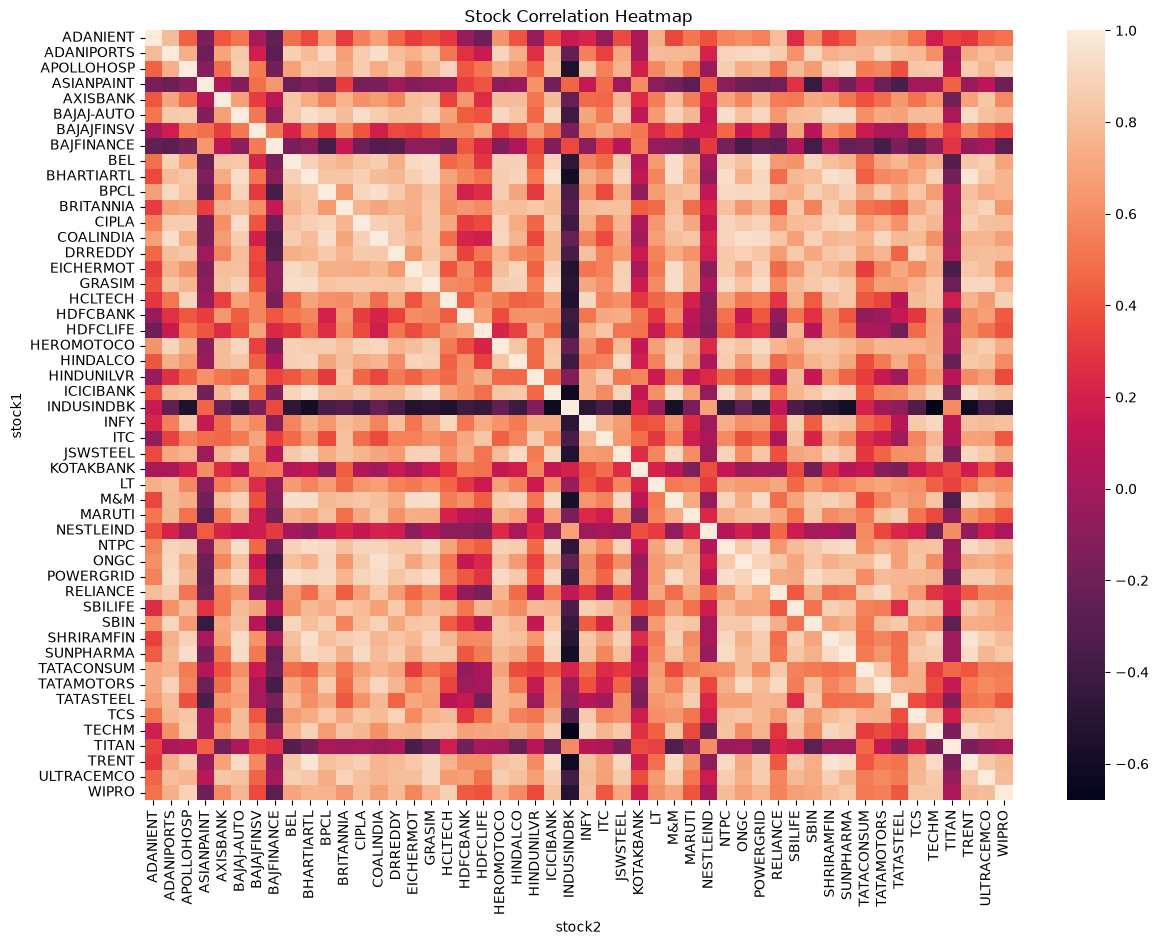

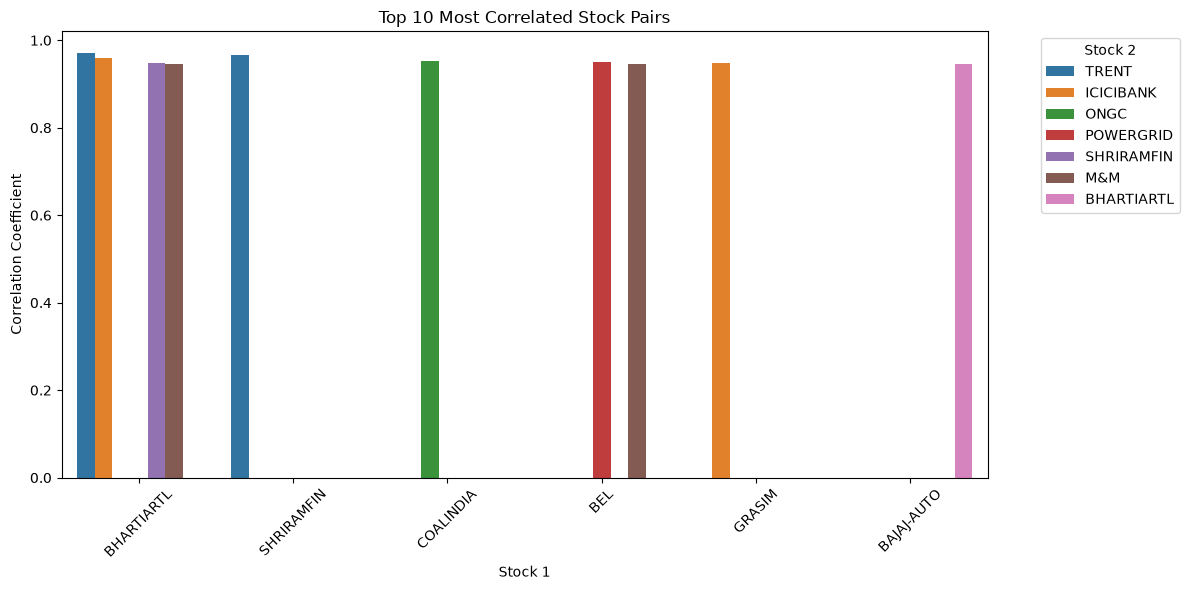

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
folder_path = "D:/stock_project/ticker_csvs"

all_dfs = []

for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        temp_df = pd.read_csv(os.path.join(folder_path, file))

        ticker = file.replace(".csv", "")
        temp_df["ticker"] = ticker

        all_dfs.append(temp_df)

df = pd.concat(all_dfs, ignore_index=True)

#print(df.head())
pivot_df = df.pivot(
    index="date",
    columns="ticker",
    values="close"
)

correlation_matrix = (
    pivot_df.corr()
)

correlation_matrix.index.name = "stock1"
correlation_matrix.columns.name = "stock2"


corr_long = (
    correlation_matrix
    .stack()
    .rename("correlation")
    .reset_index()
)

corr_long.columns = [
    "stock1",
    "stock2",
    "correlation"
]

corr_long_pair = corr_long[corr_long["stock1"] != corr_long["stock2"]]

corr_long_pair ["pair"] = corr_long_pair.apply(
    lambda row: tuple(sorted([row["stock1"], row["stock2"]])) ,
    axis=1
)

corr_long_pair = corr_long_pair.drop_duplicates(subset="pair").drop(columns="pair")

corr_long_pair.columns = [
    "stock1",
    "stock2",
    "correlation"
]

#print(corr_long_pair.head())

#Top 10 Most Correlated Pairs

top_corr = (
    corr_long_pair
    .sort_values(
        "correlation",
        ascending=False
    )
    .head(10)
)
print(top_corr) 

#Correlation Heatmap visualization


plt.figure(figsize=(14,10))

sns.heatmap(
    correlation_matrix,
    annot=False
)

plt.title(
    "Stock Correlation Heatmap"
)

plt.show()

#top 10 most correlated pairs visualization
plt.figure(figsize=(12,6))  
sns.barplot(
    data=top_corr,
    x="stock1",
    y="correlation",
    hue="stock2"
)   
plt.title("Top 10 Most Correlated Stock Pairs")
plt.xlabel("Stock 1")   
plt.ylabel("Correlation Coefficient")
plt.xticks(rotation=45)
plt.legend(title="Stock 2", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()